# FAIR-Style Cyber Risk Loss Model

This notebook models cyber risk in financial terms using:
- Threat Event Frequency (TEF)
- Loss Magnitude (LM)
- Monte Carlo simulation

Goal:
Translate cybersecurity risk into **Annualized Loss Exposure (ALE)**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Threat Event Frequency (events per year)
tef = np.random.triangular(
    left=1,    # minimum
    mode=3,    # most likely
    right=6,   # max
    size=10000
)

tef[:10]

array([2.9353039 , 5.14018292, 3.99498357, 3.54640616, 2.24907422,
       2.24897766, 1.76212605, 4.58318745, 3.55392665, 3.90741516])

In [3]:
# Loss per event (USD)
loss_magnitude = np.random.lognormal(
    mean=14.5,
    sigma=0.7,
    size=10000
)

loss_magnitude[:10]

array([ 699762.87564362,  901999.93662857, 2602994.93250509,
        871776.76927999, 4320337.20394291, 1886466.00186422,
       2105190.02200596, 1631709.70635184, 3405810.45039307,
       3430484.01504214])

In [4]:
ale = tef * loss_magnitude

ale[:10]

array([ 2054016.6985157 ,  4636444.67188033, 10398921.99577243,
        3091674.50376751,  9716759.02252188,  4242619.90072195,
        3709610.18570197,  7478431.44155066, 12104000.5312731 ,
       13404325.22974152])

In [5]:
summary = {
    "Median ALE ($)": np.percentile(ale, 50),
    "90th Percentile ($)": np.percentile(ale, 90),
    "95th Percentile ($)": np.percentile(ale, 95),
}

pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])

,Value
Median ALE ($),6.304052e+06
90th Percentile ($),1.687177e+07
95th Percentile ($),2.223618e+07


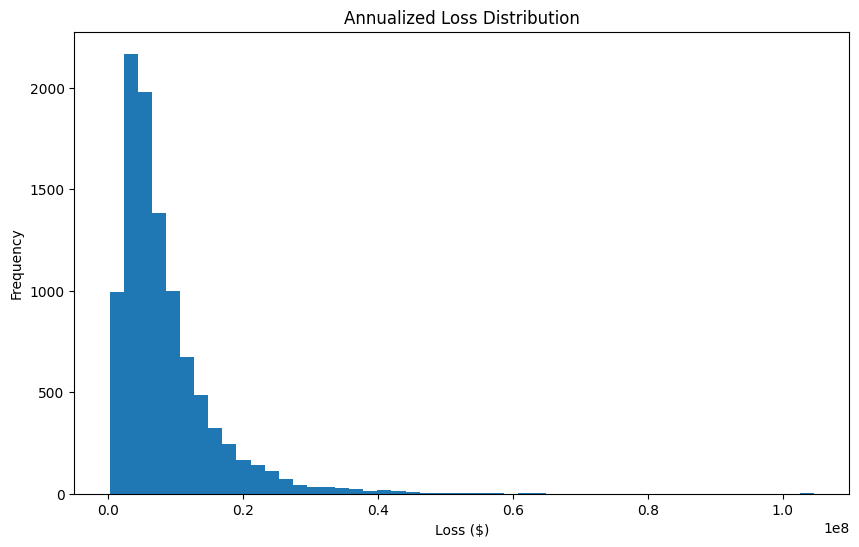

In [6]:
plt.figure(figsize=(10,6))
plt.hist(ale, bins=50)
plt.title("Annualized Loss Distribution")
plt.xlabel("Loss ($)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
sorted_ale = np.sort(ale)
cum_prob = np.arange(len(sorted_ale)) / len(sorted_ale)

plt.figure(figsize=(10,6))
plt.plot(sorted_ale, cum_prob)
plt.xlabel("Annual Loss ($)")
plt.ylabel("Cumulative Probability")
plt.title("Probability of Annual Loss Not Exceeding X")
plt.show()

In [ ]:
threshold = 10_000_000  # $10M

prob_exceed = np.mean(ale > threshold)

print(f"Probability of exceeding $10M loss: {prob_exceed:.2%}")

In [ ]:
## Key Insights

- Median annual loss is approximately $X
- There is a Y% probability of losses exceeding $10M
- Tail risk (95th percentile) is significantly higher than average

Implication:
Cyber risk should be managed as a **distribution**, not a single estimate.